In [1]:
import numpy as np
from scipy.io import readsav
import matplotlib.pyplot as plt

from spec_fitter import *
from model_spec import *

# Fit

In [2]:
e_fit_min, e_fit_max = 453, 490
spectrum = Spectrum(rawspec_sav_path='/Users/tbastro/SPI_analysis/BACKGROUND/RAW_SPEC/')
fitter = SpectrumFitter(spectrum,
    init_param_dir='/Users/tbastro/SPI_analysis/BACKGROUND/init_files',
    e_fit_min=e_fit_min, e_fit_max=e_fit_max,
)
print(spectrum)

2679 rev available


## init spectra

In [ ]:
det=None
pid=np.arange(43,3000)
spectrum.get_sumpid_spectrum(pid)


  5%|▌         | 160/2957 [00:02<00:42, 65.15it/s]


KeyboardInterrupt: 

Model: cls_plaw_function
alpha calculation
1539.0 1655.0 490 453
alpha estim -0.9255527947247153
[SUCCESS] (2000, 8)
fit_spectrum took 0.128s
Last fit: [True]
--- cont ---
 Cm= 1.5e+03 ± inf, alpha= 0.5 ± inf
--- lines ---
 E0=  455.3 ±    inf, A= 2.1e+02 ± inf, sig= 2.2e+00 ± inf, tau= 5.5e-04 ± inf
 E0=  460.1 ±    inf, A= 1.2e+02 ± inf, sig= 1.2e+00 ± inf, tau= -7.1e-01 ± inf
 E0=  464.7 ±    inf, A= 7.2e+01 ± inf, sig= 6.1e-01 ± inf, tau= -9.0e-02 ± inf
 E0=  463.2 ±    inf, A= 1.1e+02 ± inf, sig= 5.7e-02 ± inf, tau= -6.0e-04 ± inf
 E0=  468.3 ±    inf, A= 2.3e+02 ± inf, sig= 4.1e+00 ± inf, tau= 7.9e-01 ± inf
 E0=  472.8 ±    inf, A= 2.6e+03 ± inf, sig= 9.2e-01 ± inf, tau= 8.9e-01 ± inf
 E0=  474.5 ±    inf, A= 4.7e+02 ± inf, sig= 1.3e+00 ± inf, tau= 2.4e-03 ± inf
 E0=  475.1 ±    inf, A= 8.9e+02 ± inf, sig= 1.8e+00 ± inf, tau= 1.3e-01 ± inf
 E0=  478.1 ±    inf, A= 1.4e+03 ± inf, sig= 1.9e+00 ± inf, tau= 8.8e-02 ± inf
 E0=  482.3 ±    inf, A= 7.8e+02 ± inf, sig= 1.9e+00 ± inf, tau

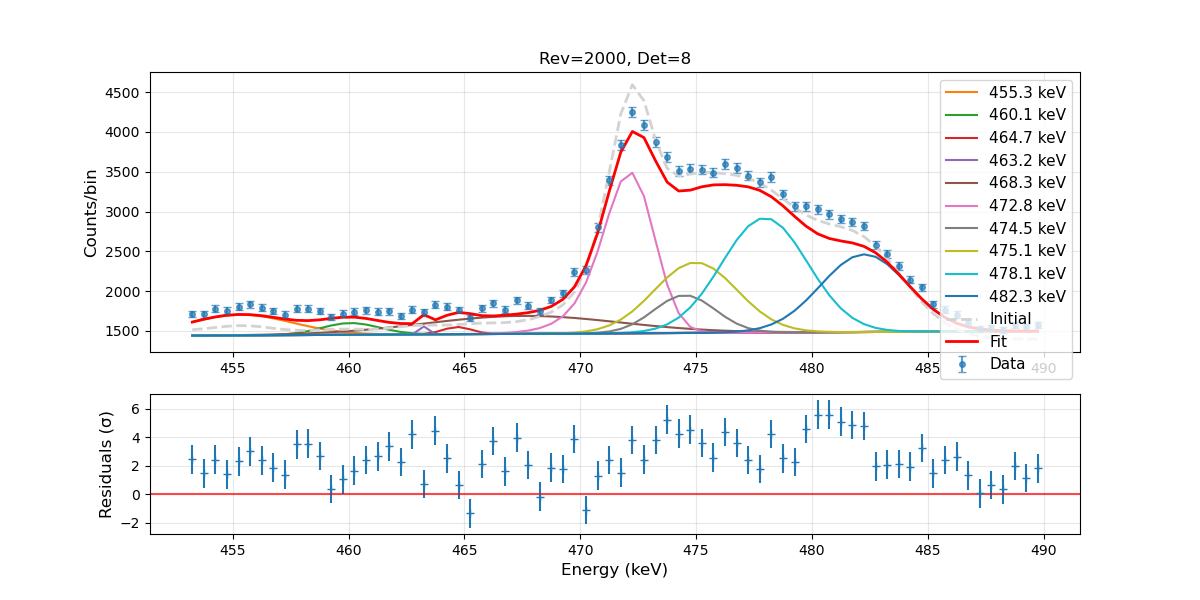

In [ ]:
%matplotlib widget
# init_params=np.array([
#             2.48589812e+03, -1.51401308e+00,
#             1.03710274e+02, 4.56449828e+02, 1.27202851e+00, 5.45206372e-04,
#             7.46836563e+01, 4.59963705e+02, 1.11658739e+00, 1.86258509e-01,
#             1.53936255e+02, 4.63057869e+02, 1.13519046e+00, 1.46281252e-01,
#             1.85514471e+02, 4.65680758e+02, 1.24119271e+00, 9.96076013e-02,
#             2.76014547e+02, 4.68894384e+02, 1.55598440e+00, 9.86497514e-02,
#             5.39734612e+03, 4.72677363e+02, 7.85477991e-01, 8.19161430e-01,
#             9.58552456e+02, 4.74394463e+02, 1.22396814e+00, 2.52747030e-01,
#             1.82996517e+03, 4.75023296e+02, 2.15508256e+00, 2.20245602e-01,
#             2.45617114e+03, 4.78012603e+02, 2.07480604e+00, 1.60892252e-01,
#             1.92510827e+03, 4.82159411e+02, 1.93228151e+00, 1.80726306e-02
#             ])
init_params=None
with_bounds=False

fitter = SpectrumFitter(
    spectrum,
    init_param_dir='/Users/tbastro/SPI_analysis/BACKGROUND/init_files',
    e_fit_min=e_fit_min, e_fit_max=e_fit_max,
    # model_name='cls_lin_function'
)
print(f"Model: {fitter.model_name}")

fitter.fit_spectrum(pid, det, verbose=True, method='scipy', maxfev=10000, init_params=init_params,
                    calc_spec=False, with_bounds=with_bounds)
# fitter.fit_spectrum_mcmc(pid,det, walker_dim_factor=5, nsteps=3000, verbose=True)
fig, axes = fitter.plot_fit(pid, det, show_initial=True, plot_lines=True, show_res=True)
# fitter.fit_results
print(fitter)
# fitter.save_last_result()

## Fit all det

[SUCCESS] (44, 0)
[SUCCESS] (44, 1)
[SUCCESS] (44, 2)
[SUCCESS] (44, 3)
[SUCCESS] (44, 4)
[SUCCESS] (44, 5)
[SUCCESS] (44, 6)
[SUCCESS] (44, 7)
[SUCCESS] (44, 8)
[SUCCESS] (44, 9)
[SUCCESS] (44, 10)
[SUCCESS] (44, 11)
[SUCCESS] (44, 12)
[SUCCESS] (44, 13)
[SUCCESS] (44, 14)
[SUCCESS] (44, 15)
[SUCCESS] (44, 16)
[SUCCESS] (44, 17)
[SUCCESS] (44, 18)

Fitted 19 detectors
Successful fits: 19


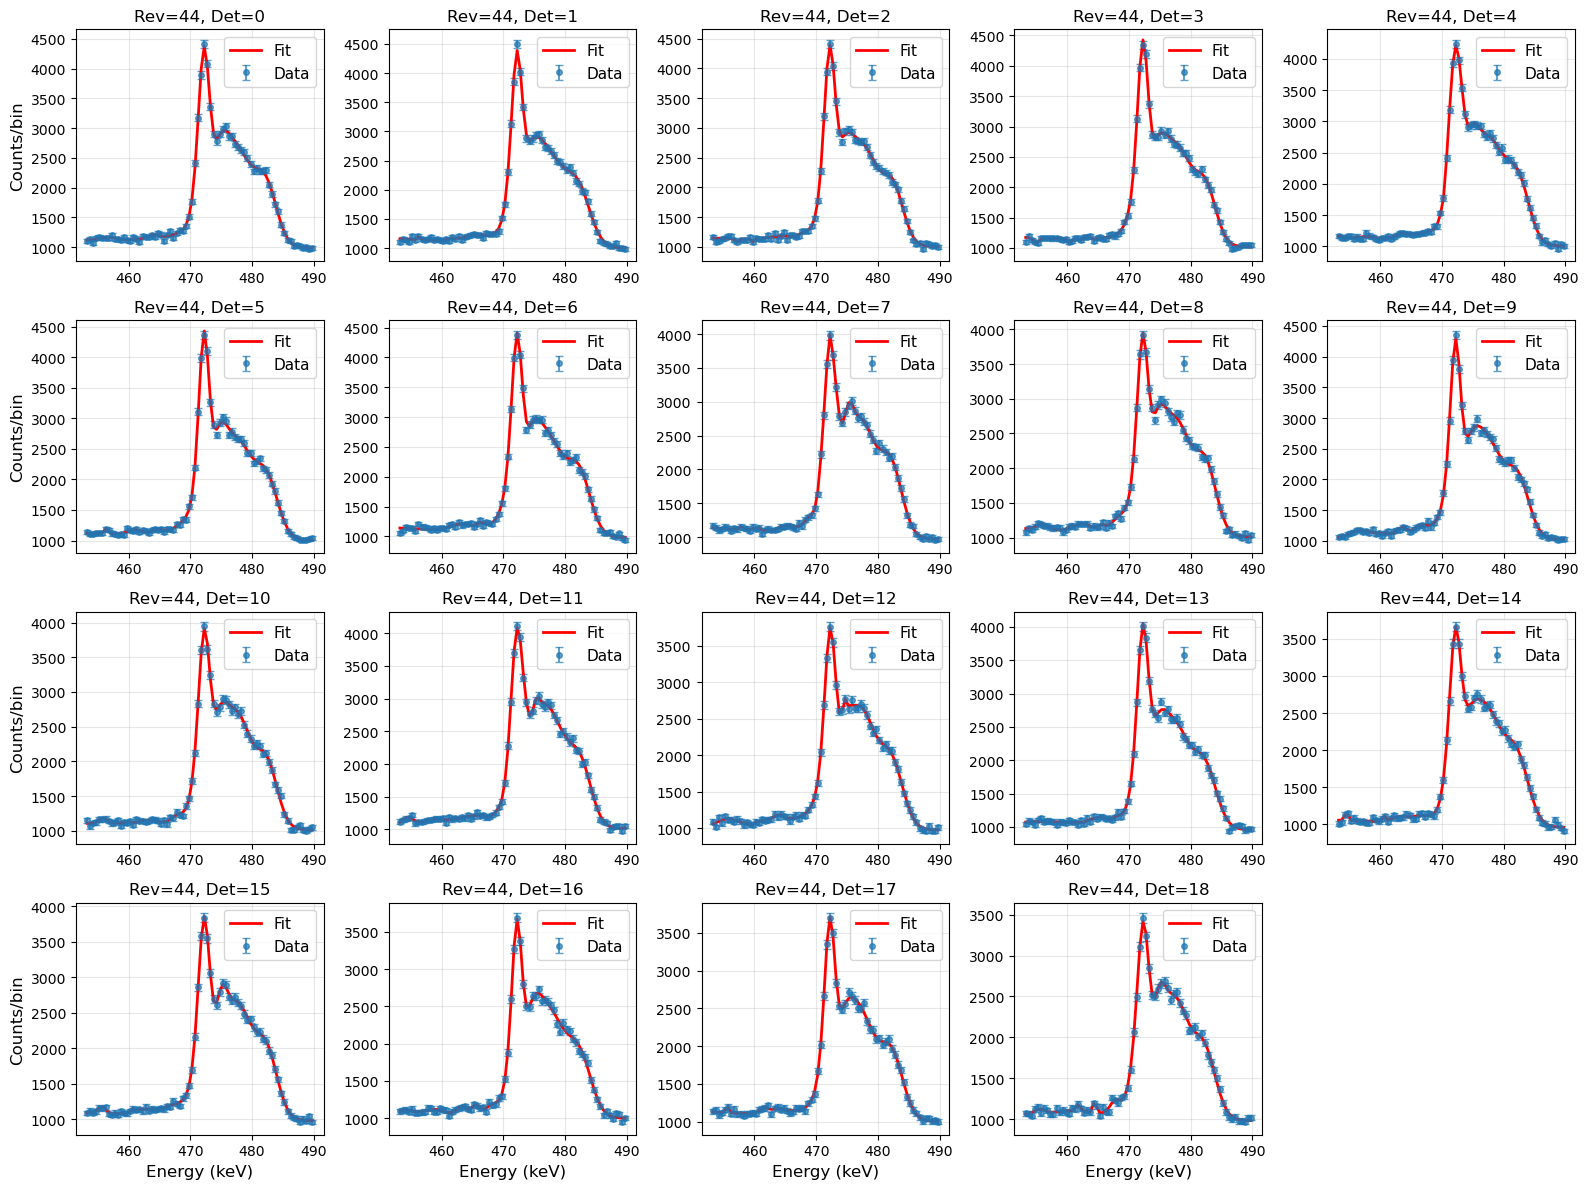

In [25]:

# Fit all detectors for a specific pid
pid = 44
e_fit_min, e_fit_max = 453, 490
init_params= np.load('fit_par_PSD_453_490keV.npy')
# fix tau to 0 if negative
# init_params= [0 if (i-2)%4==3 and init_params[i]<0 else init_params[i] for i in range(len(init_params))]
init_params=None

spectrum = Spectrum(rawspec_sav_path='/Users/tbastro/SPI_analysis/BACKGROUND/RAW_SPEC/')
spectrum.import_sav(pid)
fitter = SpectrumFitter(
    spectrum,
    init_param_dir='/Users/tbastro/SPI_analysis/BACKGROUND/init_files',
    e_fit_min=e_fit_min, e_fit_max=e_fit_max,
)
# results_all_dets = fitter.fit_all_detectors(pid, verbose=True, method='least_squares', maxfev=50000, init_params=init_params, with_bounds=False)
results_all_dets = fitter.fit_all_detectors(pid, verbose=True, method='scipy', maxfev=50000, init_params=init_params, with_bounds=False)

print(f"\nFitted {len(results_all_dets)} detectors")
print(f"Successful fits: {sum(1 for r in results_all_dets.values() if r['success'])}")

%matplotlib inline
# # Plot the fitted spectrum
# fig, ax = fitter.plot_fit(pid, det)
# plt.tight_layout()
# plt.show()
fig, axes = fitter.plot_all_detectors(pid)

## fit 1 det

[SUCCESS] (52, 9)


(<Figure size 1200x600 with 2 Axes>,
 <Axes: title={'center': 'Rev=52, Det=9'}, ylabel='Counts/bin'>)

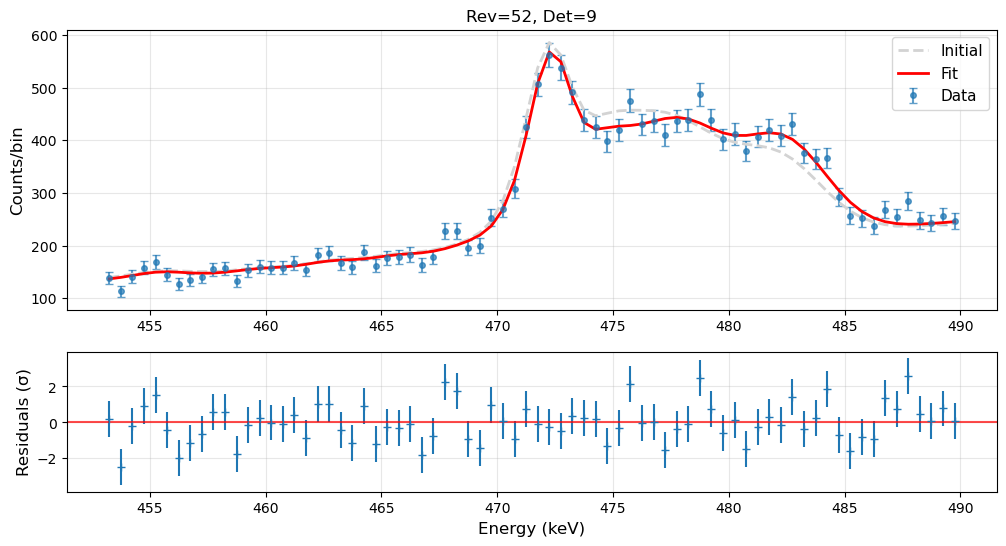

In [5]:
pid = 52
det = 9
e_fit_min, e_fit_max = 453, 490
init_params= np.load('fit_par_PSD_453_490keV.npy')
# fix tau to 0 if negative
# init_params= [0 if (i-2)%4==3 and init_params[i]<0 else init_params[i] for i in range(len(init_params))]
init_params= None

spectrum = Spectrum(rawspec_sav_path='/Users/tbastro/SPI_analysis/BACKGROUND/RAW_SPEC/')
spectrum.import_sav(pid)
fitter = SpectrumFitter(spectrum,
    init_param_dir='/Users/tbastro/SPI_analysis/BACKGROUND/init_files',
    e_fit_min=e_fit_min, e_fit_max=e_fit_max,
)
results_all_dets = fitter.fit_spectrum(pid, det, verbose=True, method='least_squares',maxfev=10000, init_params=init_params, with_bounds=False)
# results_all_dets = fitter.fit_spectrum(pid, det, verbose=True, method='scipy',maxfev=50000, init_params=init_params, with_bounds=False)
fitter.plot_fit(pid, det, show_initial=True, plot_lines=False, show_res=True)
# print(fitter)

## fit all pid

In [2]:

pid_list = np.arange(43, 2800, 1000)
e_fit_min, e_fit_max = 453, 490

spectrum = Spectrum(rawspec_sav_path='/Users/tbastro/SPI_analysis/BACKGROUND/RAW_SPEC/')
fitter = SpectrumFitter(
    spectrum,
    init_param_dir='/Users/tbastro/SPI_analysis/BACKGROUND/init_files',
    e_fit_min=e_fit_min, e_fit_max=e_fit_max,
)
# pid_list = [20,43] #[43, 1000, 2000]  # Example with multiple pids
all_results = fitter.fit_all_pids(pid_list, verbose=False, method='scipy',maxfev=50000, init_params=None,
                                  with_bounds=False , save_to_file=True)

  0%|          | 0/3 [00:00<?, ?it/s]/Users/tbastro/Documents/GitHub/spibackground/spec_fitter.py:237: OptimizeWarning: Covariance of the parameters could not be estimated
  result = curve_fit(
100%|██████████| 3/3 [00:10<00:00,  3.55s/it]

2/3 pid are valid
Filling final parameter table
0/38 fits failed
Saved to com_spec_params_e453_490_revidx_0043-2043.pkl
  - x_idx_range: shape (74,)
  - orbits: shape (2,)
  - ctime: shape (2,)
  - spec_params_det: shape (2, 42, 19, 2)
  - fit_fun: b'cls_plaw_function'
  - xc 471.5


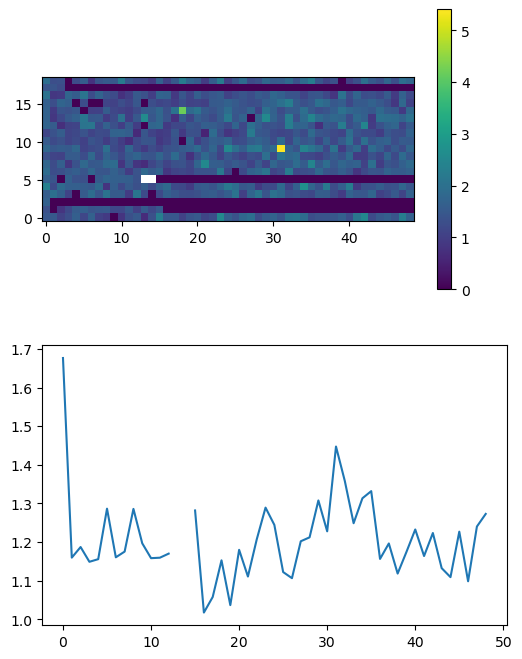

In [8]:
fig, (ax1,ax2)=plt.subplots(2,1, figsize=(6,8))
im=ax1.imshow(fitter.sav_dico['redchi2'], origin='lower')
ax2.plot(fitter.sav_dico['redchi2'].mean(axis=0))
plt.colorbar(im)

## test sav result

In [ ]:
from background_db import *

bkg_db_dir = '/Users/tbastro/SPI_analysis/BACKGROUND/BG_SAV/PSD/'
# spec_params_path_list = glob(f'{bkg_db_dir}*spec_params_e*idx_*.sav')
# spec_params_file = spec_params_path_list[4].split('/')[-1]
spec_params_file= 'com_spec_params_e453_490_revidx_0043-2043.pkl'
print(spec_params_file)
bkg_eband=BkgEband('PSD', './', spec_params_file)
print(bkg_eband)

com_spec_params_e453_490_revidx_0043-2043.pkl
